Parsed 426 subfiles, example last: 2025-10-04 10:13:00, last num: 9
Parsed 116 DMA entries, last time: 2025-10-05 05:31:05, last count: 1682, run: 19564


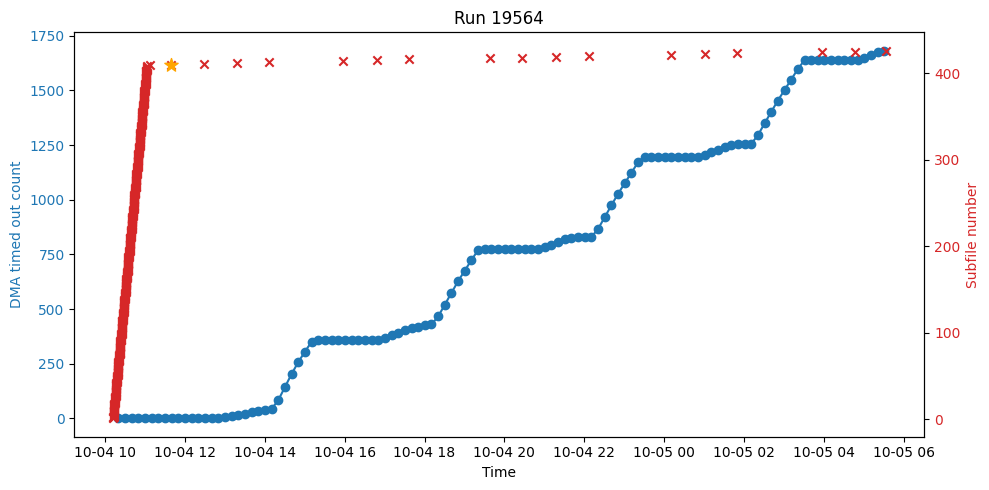

In [2]:
import matplotlib.pyplot as plt
from datetime import datetime
import re

# Read raw data from txt file
with open('/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/dma_timeout_log_run19564.txt', 'r') as f:
    data = f.read()

# Read subfile log
with open('/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/run019564_subfile_index.txt', 'r') as f_sub:
    subfile_data = f_sub.readlines()

subfile_times = []
subfile_numbers = []

# Robust regex that looks for month, day, time and filename near the end of an ls -l line.
# Handles variable spacing (e.g. 'Oct  4' where day may be right-aligned).
ls_re = re.compile(r"(?P<month>\w{3})\s+(?P<day>\d{1,2})\s+(?P<time>\d{1,2}:\d{2})\s+(?P<filename>\S+)$")

for entry in subfile_data:
    line = entry.rstrip('\n')
    m = ls_re.search(line)
    filename = None
    month_str = None
    day_str = None
    time_str = '00:00'

    if m:
        month_str = m.group('month')
        day_str = m.group('day')
        time_str = m.group('time')
        filename = m.group('filename')
    else:
        # Fallback: try to grab the last token on the line as filename and parse nearby tokens for time
        tokens = line.split()
        if not tokens:
            continue
        filename = tokens[-1]
        # try to find a token that looks like HH:MM
        time_token = None
        for t in reversed(tokens[:-1]):
            if re.match(r"^\d{1,2}:\d{2}$", t):
                time_token = t
                break
        time_str = time_token or '00:00'
        # try to find a 3-letter month token before that
        try:
            time_index = tokens.index(time_str)
            if time_index >= 2:
                month_str = tokens[time_index - 2]
                day_str = tokens[time_index - 1]
        except ValueError:
            pass

    # Determine full date: prefer ls date (month_str/day_str) when present. Only use filename date if ls fields missing.
    year = None
    month_file = None
    day_file = None

    if month_str and day_str:
        # use ls-provided month/day
        try:
            year = datetime.now().year
            month_file = datetime.strptime(month_str, '%b').month
            day_file = int(day_str)
        except Exception:
            year = None
            month_file = None
            day_file = None

    if year is None and filename:
        # fallback: try to extract date from filename (e.g. 2025.10.04)
        date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
        if date_match:
            year = int(date_match.group(1))
            month_file = int(date_match.group(2))
            day_file = int(date_match.group(3))

    if year is None:
        # couldn't determine a date
        continue

    # Parse hour and minute from the time field (default to 00:00 if missing)
    try:
        hour, minute = map(int, time_str.split(':'))
    except Exception:
        hour, minute = 0, 0

    try:
        dt = datetime(year, month_file, day_file, hour, minute)
        subfile_times.append(dt)
    except Exception:
        # skip malformed dates
        continue

    # Extract subfile number from filename using a couple of patterns
    subfile_num = None
    if filename:
        num_match = re.search(r'_subfile(\d+)_', filename)
        if not num_match:
            num_match = re.search(r'subfile(\d+)_', filename)
        if not num_match:
            # as a last resort, look for digits before _TPC
            num_match = re.search(r'_(\d{1,4})_TPC', filename)
        if num_match:
            try:
                subfile_num = int(num_match.group(1))
            except Exception:
                subfile_num = None

    if subfile_num is not None:
        subfile_numbers.append(subfile_num)

# Provide a quick check of what we parsed
print(f'Parsed {len(subfile_times)} subfiles, example last: {subfile_times[-1] if subfile_times else None}, last num: {subfile_numbers[-1] if subfile_numbers else None}')

# Parse DMA log data
lines = [line for line in data.strip().split('\n') if line]
times = []
counts = []
run_number = None

for line in lines:
    parts = [p.strip() for p in line.split('|')]
    if len(parts) < 3:
        continue
    time_str = parts[0]
    run_str = parts[1]
    count_str = parts[2]
    try:
        times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
    except Exception:
        continue
    try:
        counts.append(int(count_str.split(':')[1].strip()))
    except Exception:
        counts.append(0)
    if run_number is None:
        tokens = run_str.split()
        if len(tokens) >= 2:
            run_number = tokens[1]

print(f'Parsed {len(times)} DMA entries, last time: {times[-1] if times else None}, last count: {counts[-1] if counts else None}, run: {run_number}')

# Plot with twin y-axis
fig, ax1 = plt.subplots(figsize=(10, 5))
if times and counts:
    ax1.plot(times, counts, marker='o', color='tab:blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('DMA timed out count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title(f'Run {run_number}')

ax2 = ax1.twinx()
if subfile_times and subfile_numbers:
    ax2.scatter(subfile_times, subfile_numbers, marker='x', color='tab:red')
ax2.set_ylabel('Subfile number', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Highlight subfile 410 in a different color
if 410 in subfile_numbers:
    idx_410 = subfile_numbers.index(410)
    ax2.scatter(subfile_times[idx_410], subfile_numbers[idx_410], color='orange', s=100, marker='*', label='Subfile 410 Highlight')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Processing run 19553
Processing run 19564
Processing run 19569


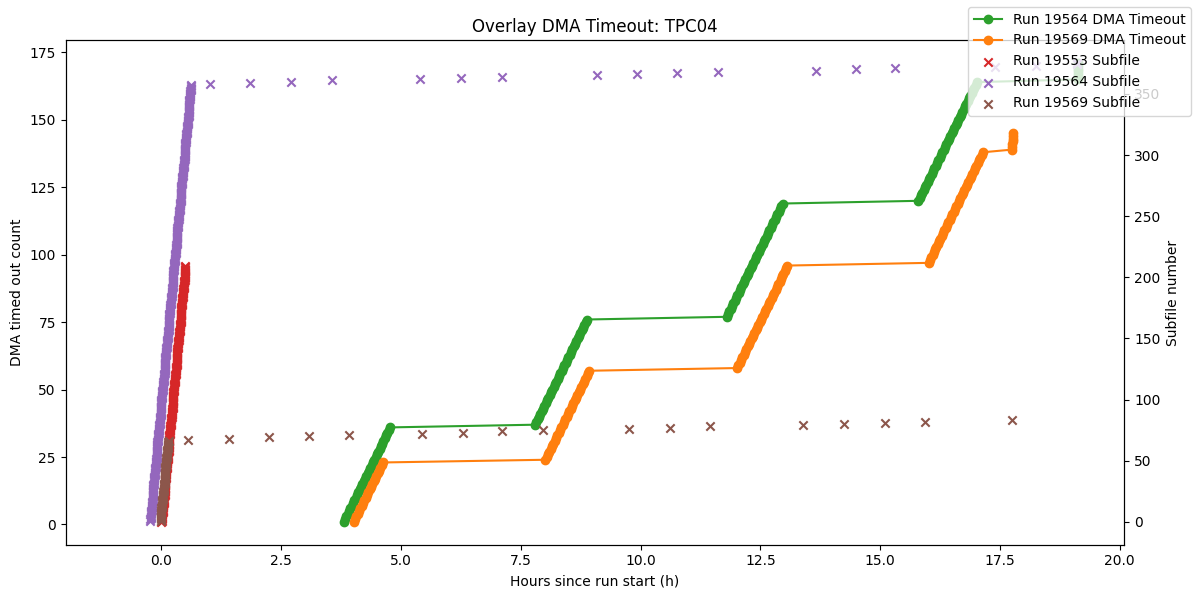

In [14]:
import matplotlib.pyplot as plt
from datetime import datetime
import re

run_numbers = [19553, 19564, 19569]  # Added run19553
plot_colors = ['tab:blue', 'tab:green', 'tab:orange']  # Unique color for each run
subfile_colors = ['tab:red', 'tab:purple', 'tab:brown']  # Unique color for each run's subfile
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
all_hours = []
for idx, run_number in enumerate(run_numbers):
    print(f'Processing run {run_number}')
    # Read and parse run data
    with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/dma_timeout_log_run{run_number}_tpc05.txt', 'r') as f:
        data = f.read()
    with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/run0{run_number}_sbnd-tpc05_subfile_index.txt', 'r') as f_sub:
        subfile_data = f_sub.readlines()
    subfile_times = []
    subfile_numbers = []
    for entry in subfile_data:
        line = entry.rstrip('\n')
        m = ls_re.search(line)
        filename = None
        month_str = None
        day_str = None
        time_str = '00:00'
        if m:
            month_str = m.group('month')
            day_str = m.group('day')
            time_str = m.group('time')
            filename = m.group('filename')
        else:
            tokens = line.split()
            if not tokens:
                continue
            filename = tokens[-1]
            time_token = None
            for t in reversed(tokens[:-1]):
                if re.match(r"^\d{1,2}:\d{2}$", t):
                    time_token = t
                    break
            time_str = time_token or '00:00'
            try:
                time_index = tokens.index(time_str)
                if time_index >= 2:
                    month_str = tokens[time_index - 2]
                    day_str = tokens[time_index - 1]
            except ValueError:
                pass
        year = None
        month_file = None
        day_file = None
        if month_str and day_str:
            try:
                year = datetime.now().year
                month_file = datetime.strptime(month_str, '%b').month
                day_file = int(day_str)
            except Exception:
                year = None
                month_file = None
                day_file = None
        if year is None and filename:
            date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
            if date_match:
                year = int(date_match.group(1))
                month_file = int(date_match.group(2))
                day_file = int(date_match.group(3))
        if year is None:
            continue
        try:
            hour, minute = map(int, time_str.split(':'))
        except Exception:
            hour, minute = 0, 0
        try:
            dt = datetime(year, month_file, day_file, hour, minute)
            subfile_times.append(dt)
        except Exception:
            continue
        subfile_num = None
        if filename:
            num_match = re.search(r'_subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'_(\d{1,4})_TPC', filename)
            if num_match:
                try:
                    subfile_num = int(num_match.group(1))
                except Exception:
                    subfile_num = None
        if subfile_num is not None:
            subfile_numbers.append(subfile_num)
    lines = [line for line in data.strip().split('\n') if line]
    times = []
    counts = []
    run_number_str = None
    for line in lines:
        parts = [p.strip() for p in line.split('|')]
        if len(parts) < 3:
            continue
        time_str = parts[0]
        run_str = parts[1]
        count_str = parts[2]
        try:
            times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
        except Exception:
            continue
        try:
            counts.append(int(count_str.split(':')[1].strip()))
        except Exception:
            counts.append(0)
        if run_number_str is None:
            tokens = run_str.split()
            if len(tokens) >= 2:
                run_number_str = tokens[1]
    reference_start = None
    if times:
        reference_start = subfile_times[0]
    if reference_start is None and subfile_times:
        reference_start = subfile_times[0]
    times_h = [(t - reference_start).total_seconds() / 3600.0 for t in times] if reference_start and times else []
    subfile_times_h = [(t - reference_start).total_seconds() / 3600.0 for t in subfile_times] if reference_start and subfile_times else []
    all_hours.extend(times_h if times_h else [])
    all_hours.extend(subfile_times_h if subfile_times_h else [])
    # Plot DMA counts vs hours since each run's start
    if times_h and counts:
        ax1.plot(times_h, counts, marker='o', color=plot_colors[idx % len(plot_colors)], label=f'Run {run_number} DMA Timeout')
    if subfile_times_h and subfile_numbers:
        ax2.scatter(subfile_times_h, subfile_numbers, marker='x', color=subfile_colors[idx % len(subfile_colors)], label=f'Run {run_number} Subfile')
ax1.set_xlabel('Hours since run start (h)')
ax1.set_ylabel('DMA timed out count')
ax1.tick_params(axis='y')
ax1.set_title('Overlay DMA Timeout: TPC04')
ax2.set_ylabel('Subfile number')
ax2.tick_params(axis='y')
if all_hours:
    ax1.set_xlim(left=-2, right=max(all_hours) * 1.05)
fig.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Processing TPC 1
Parsed 238 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 3170 DMA entries, last time: 2025-10-11 16:33:45, last count: 3170, run: 19615


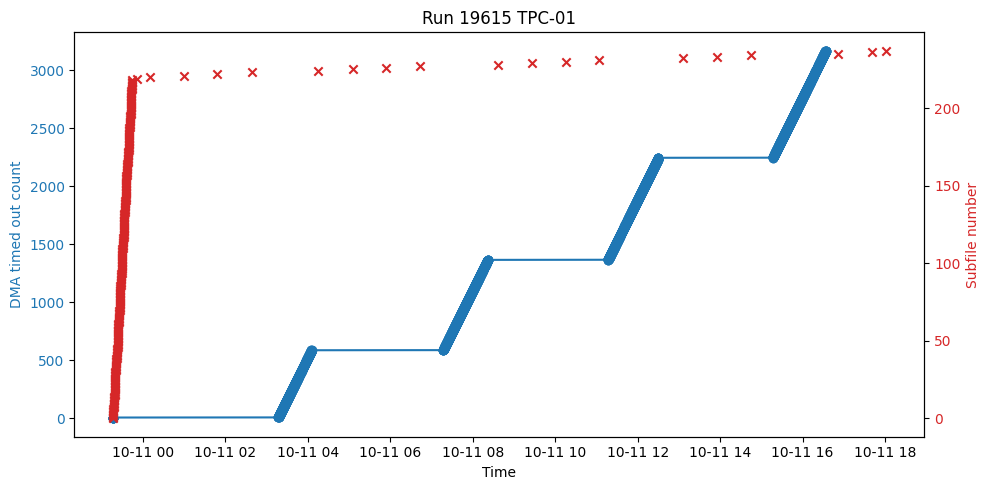

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 2
Parsed 298 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 3276 DMA entries, last time: 2025-10-11 17:31:50, last count: 3276, run: 19615


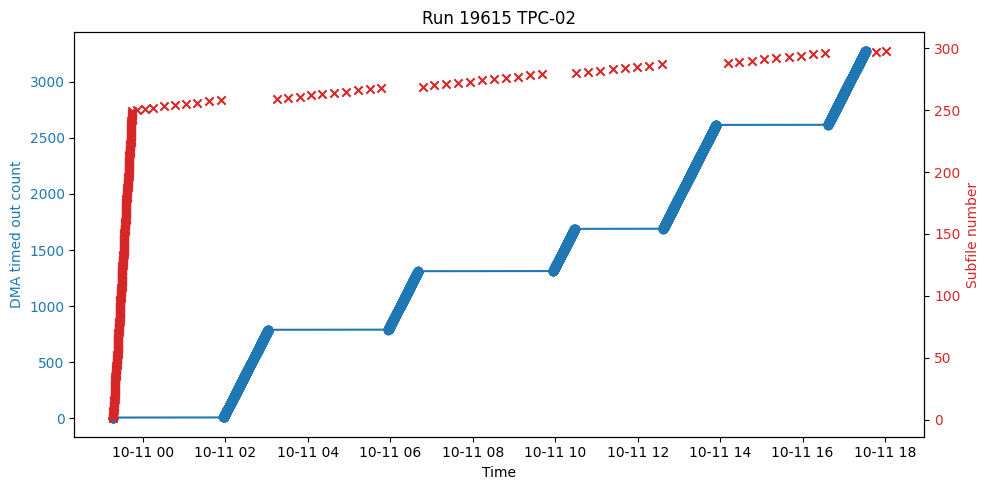

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 3
Parsed 318 subfiles, example last: 2025-10-10 23:17:00, last num: 9
Parsed 2916 DMA entries, last time: 2025-10-11 16:27:24, last count: 2916, run: 19615


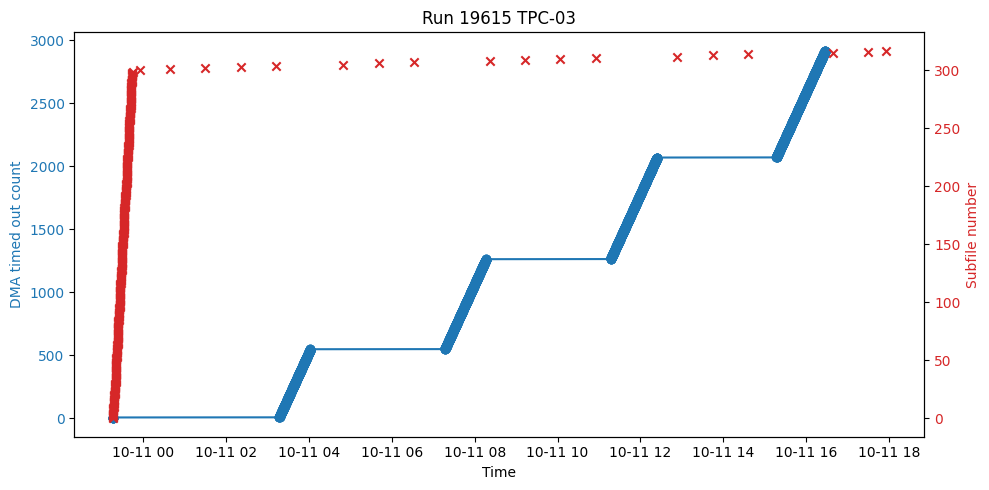

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 4
Parsed 241 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 3134 DMA entries, last time: 2025-10-11 16:32:18, last count: 3134, run: 19615


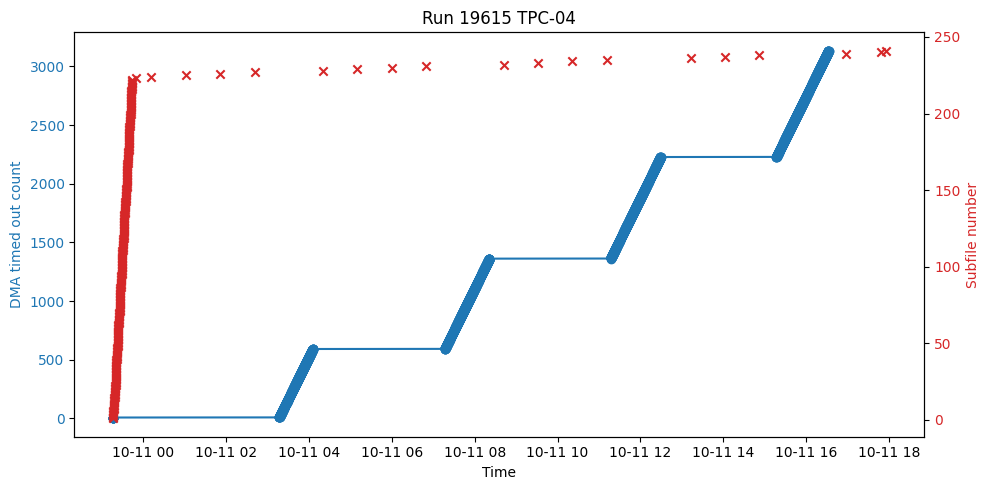

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 5
Parsed 213 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 2982 DMA entries, last time: 2025-10-11 16:28:29, last count: 2982, run: 19615


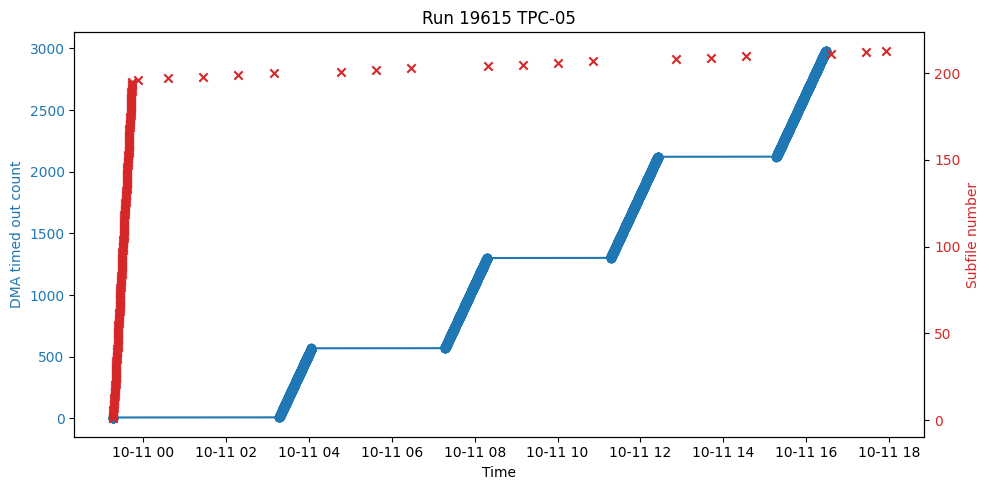

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 6
Parsed 328 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 2685 DMA entries, last time: 2025-10-11 17:06:42, last count: 2685, run: 19615


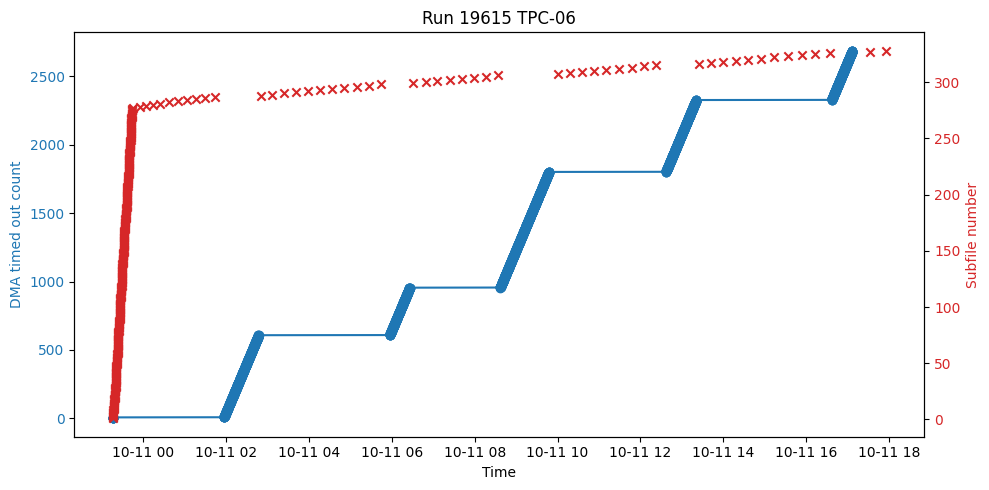

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 7
Parsed 334 subfiles, example last: 2025-10-10 23:17:00, last num: 9
Parsed 3032 DMA entries, last time: 2025-10-11 16:30:23, last count: 3032, run: 19615


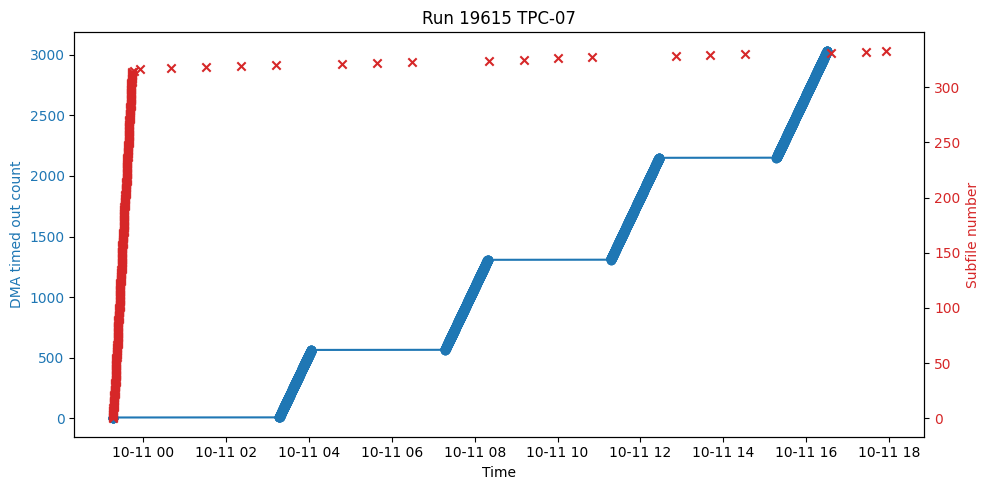

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 8
Parsed 226 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 2965 DMA entries, last time: 2025-10-11 16:27:47, last count: 2965, run: 19615


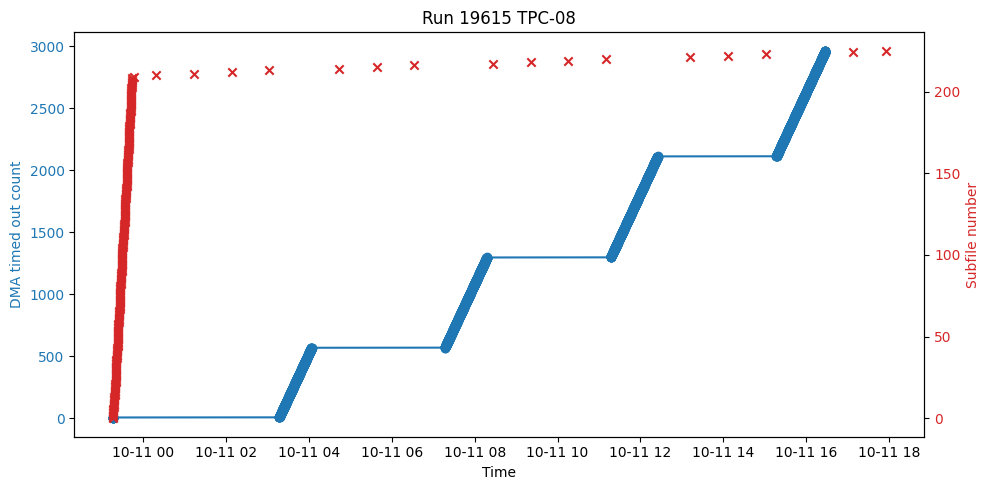

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 9
Parsed 233 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 3123 DMA entries, last time: 2025-10-11 16:31:52, last count: 3123, run: 19615


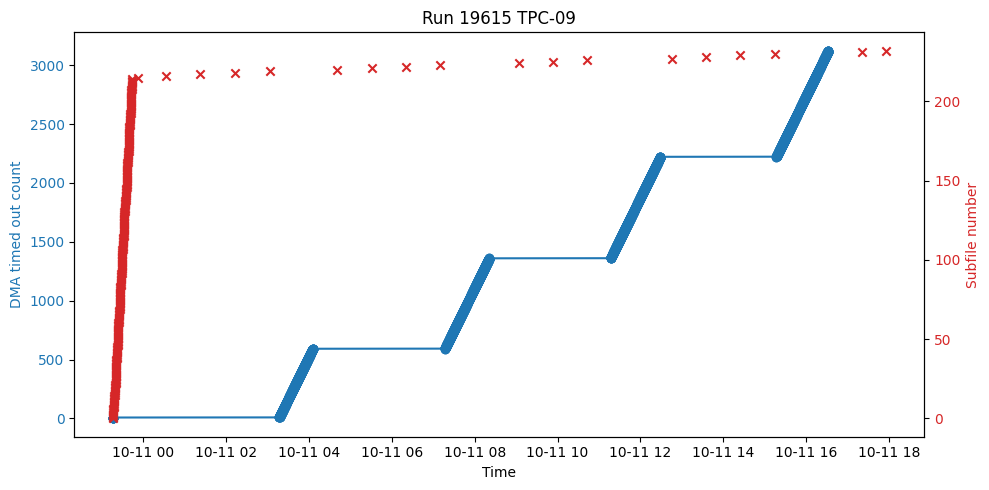

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 10
Parsed 243 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 6054 DMA entries, last time: 2025-10-11 17:47:17, last count: 6054, run: 19615


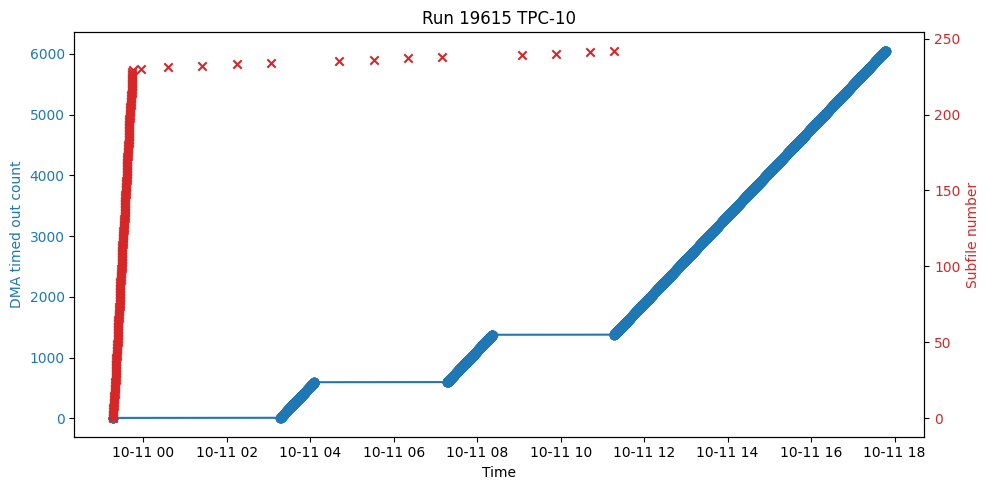

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf
Processing TPC 11
Parsed 279 subfiles, example last: 2025-10-10 23:18:00, last num: 9
Parsed 2574 DMA entries, last time: 2025-10-11 14:39:33, last count: 2574, run: 19615


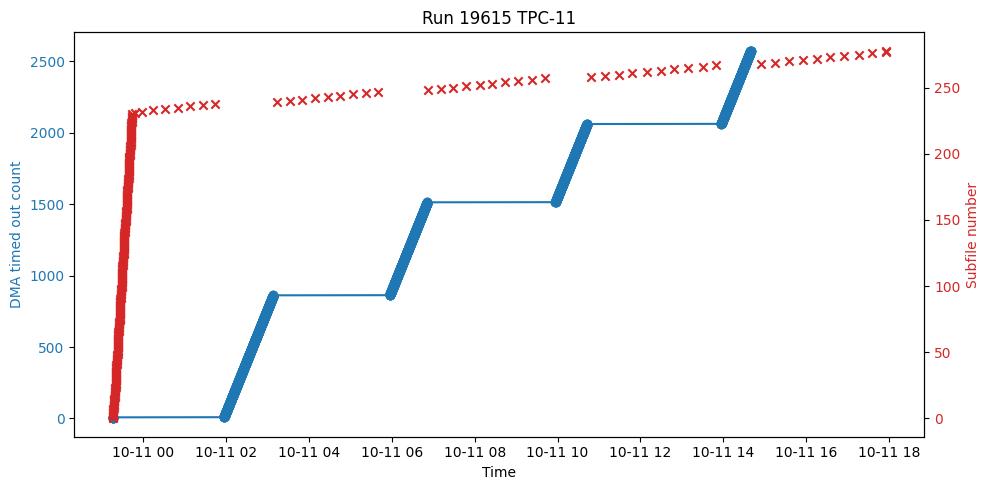

Processing TPC 1 (PDF)
Processing TPC 2 (PDF)
Processing TPC 3 (PDF)
Processing TPC 4 (PDF)
Processing TPC 5 (PDF)
Processing TPC 6 (PDF)
Processing TPC 7 (PDF)
Processing TPC 8 (PDF)
Processing TPC 9 (PDF)
Processing TPC 10 (PDF)
Processing TPC 11 (PDF)
All plots saved to run19615_all_tpc_plots.pdf


In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime
import re
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

tpcs = [i for i in range(1,12)]  # Added run19553
run_number = 19615

plot_colors = ['tab:blue']  # Unique color for each run
subfile_colors = [
    'tab:red', 'tab:purple', 'tab:brown', 'tab:orange',
    'tab:green', 'tab:pink', 'tab:gray', 'tab:olive',
    'tab:cyan', 'tab:blue', 'tab:orange'
]

for tpc in tpcs:
    print(f'Processing TPC {tpc}')

    # Read raw data from txt file
    with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/dma_timeout_log_run{run_number}_tpc{tpc:02d}.txt', 'r') as f:
        data = f.read()

    # Read subfile log
    with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/run0{run_number}_sbnd-tpc{tpc:02d}_subfile_index.txt', 'r') as f_sub:
        subfile_data = f_sub.readlines()

    subfile_times = []
    subfile_numbers = []

    # Robust regex that looks for month, day, time and filename near the end of an ls -l line.
    # Handles variable spacing (e.g. 'Oct  4' where day may be right-aligned).
    ls_re = re.compile(r"(?P<month>\w{3})\s+(?P<day>\d{1,2})\s+(?P<time>\d{1,2}:\d{2})\s+(?P<filename>\S+)$")

    for entry in subfile_data:
        line = entry.rstrip('\n')
        m = ls_re.search(line)
        filename = None
        month_str = None
        day_str = None
        time_str = '00:00'

        if m:
            month_str = m.group('month')
            day_str = m.group('day')
            time_str = m.group('time')
            filename = m.group('filename')
        else:
            # Fallback: try to grab the last token on the line as filename and parse nearby tokens for time
            tokens = line.split()
            if not tokens:
                continue
            filename = tokens[-1]
            # try to find a token that looks like HH:MM
            time_token = None
            for t in reversed(tokens[:-1]):
                if re.match(r"^\d{1,2}:\d{2}$", t):
                    time_token = t
                    break
            time_str = time_token or '00:00'
            # try to find a 3-letter month token before that
            try:
                time_index = tokens.index(time_str)
                if time_index >= 2:
                    month_str = tokens[time_index - 2]
                    day_str = tokens[time_index - 1]
            except ValueError:
                pass

        # Determine full date: prefer ls date (month_str/day_str) when present. Only use filename date if ls fields missing.
        year = None
        month_file = None
        day_file = None

        if month_str and day_str:
            # use ls-provided month/day
            try:
                year = datetime.now().year
                month_file = datetime.strptime(month_str, '%b').month
                day_file = int(day_str)
            except Exception:
                year = None
                month_file = None
                day_file = None

        if year is None and filename:
            # fallback: try to extract date from filename (e.g. 2025.10.04)
            date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
            if date_match:
                year = int(date_match.group(1))
                month_file = int(date_match.group(2))
                day_file = int(date_match.group(3))

        if year is None:
            # couldn't determine a date
            continue

        # Parse hour and minute from the time field (default to 00:00 if missing)
        try:
            hour, minute = map(int, time_str.split(':'))
        except Exception:
            hour, minute = 0, 0

        try:
            dt = datetime(year, month_file, day_file, hour, minute)
            subfile_times.append(dt)
        except Exception:
            # skip malformed dates
            continue

        # Extract subfile number from filename using a couple of patterns
        subfile_num = None
        if filename:
            num_match = re.search(r'_subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'subfile(\d+)_', filename)
            if not num_match:
                # as a last resort, look for digits before _TPC
                num_match = re.search(r'_(\d{1,4})_TPC', filename)
            if num_match:
                try:
                    subfile_num = int(num_match.group(1))
                except Exception:
                    subfile_num = None

        if subfile_num is not None:
            subfile_numbers.append(subfile_num)

    # Provide a quick check of what we parsed
    print(f'Parsed {len(subfile_times)} subfiles, example last: {subfile_times[-1] if subfile_times else None}, last num: {subfile_numbers[-1] if subfile_numbers else None}')

    # Parse DMA log data
    lines = [line for line in data.strip().split('\n') if line]
    times = []
    counts = []
    run_number = None

    for line in lines:
        parts = [p.strip() for p in line.split('|')]
        if len(parts) < 3:
            continue
        time_str = parts[0]
        run_str = parts[1]
        count_str = parts[2]
        try:
            times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
        except Exception:
            continue
        try:
            counts.append(int(count_str.split(':')[1].strip()))
        except Exception:
            counts.append(0)
        if run_number is None:
            tokens = run_str.split()
            if len(tokens) >= 2:
                run_number = tokens[1]

    print(f'Parsed {len(times)} DMA entries, last time: {times[-1] if times else None}, last count: {counts[-1] if counts else None}, run: {run_number}')

    # Plot with twin y-axis
    fig, ax1 = plt.subplots(figsize=(10, 5))
    if times and counts:
        ax1.plot(times, counts, marker='o', color='tab:blue')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('DMA timed out count', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_title(f'Run {run_number} TPC-{tpc:02d}')

    ax2 = ax1.twinx()
    if subfile_times and subfile_numbers:
        ax2.scatter(subfile_times, subfile_numbers, marker='x', color='tab:red')
    ax2.set_ylabel('Subfile number', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    pdf_filename = 'run{}_all_tpc_plots.pdf'.format(run_number)
    with PdfPages(pdf_filename) as pdf:
        for tpc in tpcs:

            print(f'Processing TPC {tpc} (PDF)')
            # Repeat the parsing and plotting logic for each TPC
            # (reuse your parsing code above, but do not call plt.show())
            # Read raw data from txt file
            with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/dma_timeout_log_run{run_number}_tpc{tpc:02d}.txt', 'r') as f:
                data = f.read()
            with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/run0{run_number}_sbnd-tpc{tpc:02d}_subfile_index.txt', 'r') as f_sub:
                subfile_data = f_sub.readlines()
            subfile_times = []
            subfile_numbers = []
            for entry in subfile_data:
                line = entry.rstrip('\n')
                m = ls_re.search(line)
                filename = None
                month_str = None
                day_str = None
                time_str = '00:00'
                if m:
                    month_str = m.group('month')
                    day_str = m.group('day')
                    time_str = m.group('time')
                    filename = m.group('filename')
                else:
                    tokens = line.split()
                    if not tokens:
                        continue
                    filename = tokens[-1]
                    time_token = None
                    for t in reversed(tokens[:-1]):
                        if re.match(r"^\d{1,2}:\d{2}$", t):
                            time_token = t
                            break
                    time_str = time_token or '00:00'
                    try:
                        time_index = tokens.index(time_str)
                        if time_index >= 2:
                            month_str = tokens[time_index - 2]
                            day_str = tokens[time_index - 1]
                    except ValueError:
                        pass
                year = None
                month_file = None
                day_file = None
                if month_str and day_str:
                    try:
                        year = datetime.now().year
                        month_file = datetime.strptime(month_str, '%b').month
                        day_file = int(day_str)
                    except Exception:
                        year = None
                        month_file = None
                        day_file = None
                if year is None and filename:
                    date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
                    if date_match:
                        year = int(date_match.group(1))
                        month_file = int(date_match.group(2))
                        day_file = int(date_match.group(3))
                if year is None:
                    continue
                try:
                    hour, minute = map(int, time_str.split(':'))
                except Exception:
                    hour, minute = 0, 0
                try:
                    dt = datetime(year, month_file, day_file, hour, minute)
                    subfile_times.append(dt)
                except Exception:
                    continue
                subfile_num = None
                if filename:
                    num_match = re.search(r'_subfile(\d+)_', filename)
                    if not num_match:
                        num_match = re.search(r'subfile(\d+)_', filename)
                    if not num_match:
                        num_match = re.search(r'_(\d{1,4})_TPC', filename)
                    if num_match:
                        try:
                            subfile_num = int(num_match.group(1))
                        except Exception:
                            subfile_num = None
                if subfile_num is not None:
                    subfile_numbers.append(subfile_num)
            lines = [line for line in data.strip().split('\n') if line]
            times = []
            counts = []
            run_number_str = None
            for line in lines:
                parts = [p.strip() for p in line.split('|')]
                if len(parts) < 3:
                    continue
                time_str = parts[0]
                run_str = parts[1]
                count_str = parts[2]
                try:
                    times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
                except Exception:
                    continue
                try:
                    counts.append(int(count_str.split(':')[1].strip()))
                except Exception:
                    counts.append(0)
                if run_number_str is None:
                    tokens = run_str.split()
                    if len(tokens) >= 2:
                        run_number_str = tokens[1]
            fig, ax1 = plt.subplots(figsize=(10, 5))
            if times and counts:
                ax1.plot(times, counts, marker='o', color='tab:blue')
            ax1.set_xlabel('Time')
            ax1.set_ylabel('DMA timed out count', color='tab:blue')
            ax1.tick_params(axis='y', labelcolor='tab:blue')
            ax1.set_title(f'Run {run_number} TPC-{tpc:02d}')
            ax2 = ax1.twinx()
            if subfile_times and subfile_numbers:
                ax2.scatter(subfile_times, subfile_numbers, marker='x', color='tab:red')
            ax2.set_ylabel('Subfile number', color='tab:red')
            ax2.tick_params(axis='y', labelcolor='tab:red')
            # Only fit if there are at least 5 points


            plt.xticks(rotation=45)
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)
    print(f'All plots saved to {pdf_filename}')

FileNotFoundError: [Errno 2] No such file or directory: 'dma_timeout_log_run19564.txt'

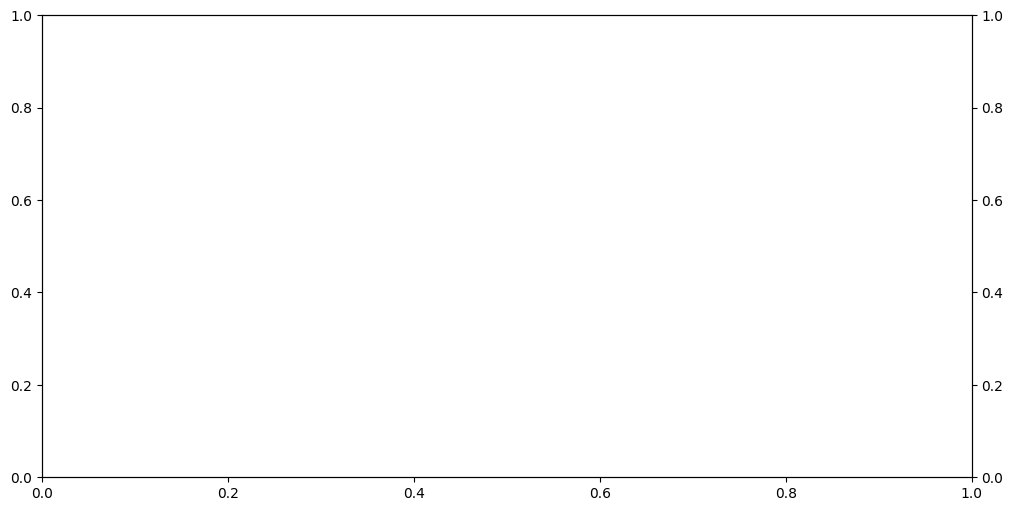

In [37]:
tpcs = [i for i in range(1,12)]  # Added run19553
run_number = 19564

subfile_colors = [
    'tab:red', 'tab:purple', 'tab:brown', 'tab:orange',
    'tab:green', 'tab:pink', 'tab:gray', 'tab:olive',
    'tab:cyan', 'tab:blue', 'tab:orange'
]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
all_hours = []

with open(f'dma_timeout_log_run{run_number}.txt', 'r') as f:
    data = f.read()


lines = [line for line in data.strip().split('\n') if line]
times = []
counts = []
run_number_str = None
for line in lines:
    parts = [p.strip() for p in line.split('|')]
    if len(parts) < 3:
        continue
    time_str = parts[0]
    run_str = parts[1]
    count_str = parts[2]
    try:
        times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
    except Exception:
        continue
    try:
        counts.append(int(count_str.split(':')[1].strip()))
    except Exception:
        counts.append(0)
    if run_number_str is None:
        tokens = run_str.split()
        if len(tokens) >= 2:
            run_number_str = tokens[1]
reference_start = None
if times:
    reference_start = times[0]
if reference_start is None and subfile_times:
    reference_start = subfile_times[0]
times_h = [(t - reference_start).total_seconds() / 3600.0 for t in times] if reference_start and times else []

if times_h and counts:
    ax1.plot(times_h, counts, marker='o', c=plot_colors[idx % len(plot_colors)], label=f'DMA Timeout')


for idx, tpc in enumerate(tpcs):
    print(f'Processing run {tpc}')
    # Read and parse run data
    with open(f'run0{run_number}_sbnd-tpc{tpc:02d}_subfile_index.txt', 'r') as f_sub:
        subfile_data = f_sub.readlines()
    subfile_times = []
    subfile_numbers = []
    for entry in subfile_data:
        line = entry.rstrip('\n')
        m = ls_re.search(line)
        filename = None
        month_str = None
        day_str = None
        time_str = '00:00'
        if m:
            month_str = m.group('month')
            day_str = m.group('day')
            time_str = m.group('time')
            filename = m.group('filename')
        else:
            tokens = line.split()
            if not tokens:
                continue
            filename = tokens[-1]
            time_token = None
            for t in reversed(tokens[:-1]):
                if re.match(r"^\d{1,2}:\d{2}$", t):
                    time_token = t
                    break
            time_str = time_token or '00:00'
            try:
                time_index = tokens.index(time_str)
                if time_index >= 2:
                    month_str = tokens[time_index - 2]
                    day_str = tokens[time_index - 1]
            except ValueError:
                pass
        year = None
        month_file = None
        day_file = None
        if month_str and day_str:
            try:
                year = datetime.now().year
                month_file = datetime.strptime(month_str, '%b').month
                day_file = int(day_str)
            except Exception:
                year = None
                month_file = None
                day_file = None
        if year is None and filename:
            date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
            if date_match:
                year = int(date_match.group(1))
                month_file = int(date_match.group(2))
                day_file = int(date_match.group(3))
        if year is None:
            continue
        try:
            hour, minute = map(int, time_str.split(':'))
        except Exception:
            hour, minute = 0, 0
        try:
            dt = datetime(year, month_file, day_file, hour, minute)
            subfile_times.append(dt)
        except Exception:
            continue
        subfile_num = None
        if filename:
            num_match = re.search(r'_subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'_(\d{1,4})_TPC', filename)
            if num_match:
                try:
                    subfile_num = int(num_match.group(1))
                except Exception:
                    subfile_num = None
        if subfile_num is not None:
            subfile_numbers.append(subfile_num)
    subfile_times_h = [(t - reference_start).total_seconds() / 3600.0 for t in subfile_times] if reference_start and subfile_times else []
    all_hours.extend(times_h if times_h else [])
    all_hours.extend(subfile_times_h if subfile_times_h else [])
    # Plot DMA counts vs hours since each run's start
    if subfile_times_h and subfile_numbers:
        ax2.scatter(subfile_times_h, subfile_numbers, marker='x', c=subfile_colors[idx % len(subfile_colors)], label=f'TPC {tpc}')
ax1.set_xlabel('Hours since run start (h)')
ax1.set_ylabel('DMA timed out count')
ax1.tick_params(axis='y')
ax1.set_title(f'Run {run_number}')
ax2.set_ylabel('Subfile number')
ax2.tick_params(axis='y')
if all_hours:
    ax1.set_xlim(left=0, right=max(all_hours) * 1.05)
fig.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Processing run 1
Processing run 2
Processing run 3
Processing run 4
Processing run 5
Processing run 6
Processing run 7
Processing run 8
Processing run 9
Processing run 10
Processing run 11


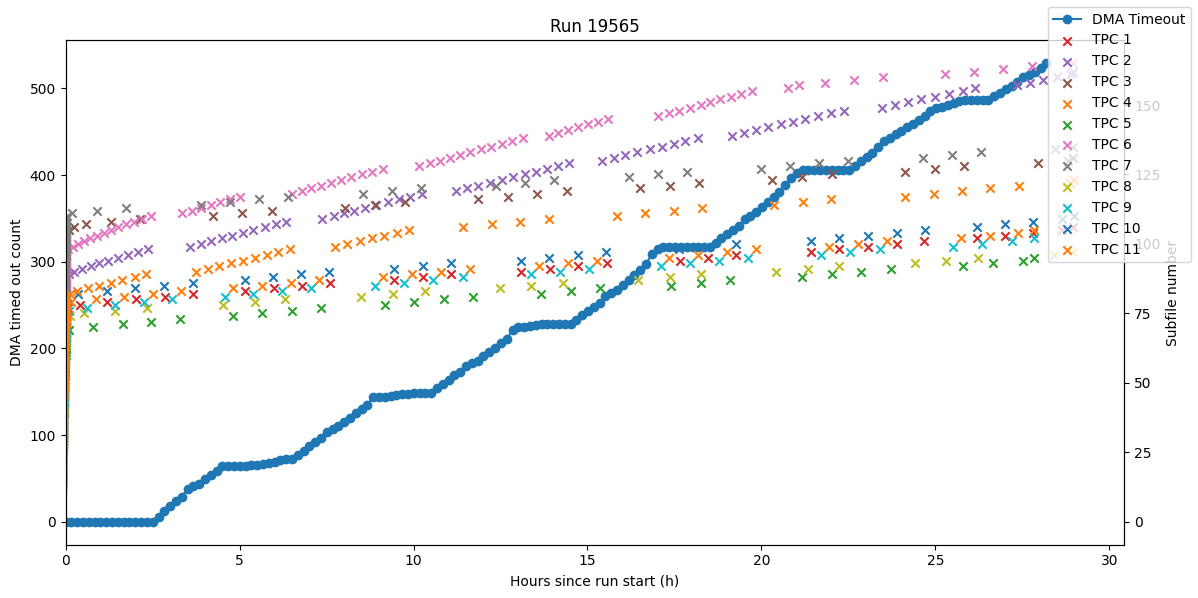

In [50]:
tpcs = [i for i in range(1,12)]  # Added run19553
run_number = 19565

plot_colors = ['tab:blue']  # Unique color for each run
subfile_colors = [
    'tab:red', 'tab:purple', 'tab:brown', 'tab:orange',
    'tab:green', 'tab:pink', 'tab:gray', 'tab:olive',
    'tab:cyan', 'tab:blue', 'tab:orange'
]
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
all_hours = []

with open(f'dma_timeout_log_run{run_number}.txt', 'r') as f:
    data = f.read()


lines = [line for line in data.strip().split('\n') if line]
times = []
counts = []
run_number_str = None
for line in lines:
    parts = [p.strip() for p in line.split('|')]
    if len(parts) < 3:
        continue
    time_str = parts[0]
    run_str = parts[1]
    count_str = parts[2]
    try:
        times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
    except Exception:
        continue
    try:
        counts.append(int(count_str.split(':')[1].strip()))
    except Exception:
        counts.append(0)
    if run_number_str is None:
        tokens = run_str.split()
        if len(tokens) >= 2:
            run_number_str = tokens[1]
reference_start = None
if times:
    reference_start = times[0]
if reference_start is None and subfile_times:
    reference_start = subfile_times[0]
times_h = [(t - reference_start).total_seconds() / 3600.0 for t in times] if reference_start and times else []

if times_h and counts:
    ax1.plot(times_h, counts, marker='o', c=plot_colors[idx % len(plot_colors)], label=f'DMA Timeout')


for idx, tpc in enumerate(tpcs):
    print(f'Processing run {tpc}')
    # Read and parse run data
    with open(f'run0{run_number}_sbnd-tpc{tpc:02d}_subfile_index.txt', 'r') as f_sub:
        subfile_data = f_sub.readlines()
    subfile_times = []
    subfile_numbers = []
    for entry in subfile_data:
        line = entry.rstrip('\n')
        m = ls_re.search(line)
        filename = None
        month_str = None
        day_str = None
        time_str = '00:00'
        if m:
            month_str = m.group('month')
            day_str = m.group('day')
            time_str = m.group('time')
            filename = m.group('filename')
        else:
            tokens = line.split()
            if not tokens:
                continue
            filename = tokens[-1]
            time_token = None
            for t in reversed(tokens[:-1]):
                if re.match(r"^\d{1,2}:\d{2}$", t):
                    time_token = t
                    break
            time_str = time_token or '00:00'
            try:
                time_index = tokens.index(time_str)
                if time_index >= 2:
                    month_str = tokens[time_index - 2]
                    day_str = tokens[time_index - 1]
            except ValueError:
                pass
        year = None
        month_file = None
        day_file = None
        if month_str and day_str:
            try:
                year = datetime.now().year
                month_file = datetime.strptime(month_str, '%b').month
                day_file = int(day_str)
            except Exception:
                year = None
                month_file = None
                day_file = None
        if year is None and filename:
            date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
            if date_match:
                year = int(date_match.group(1))
                month_file = int(date_match.group(2))
                day_file = int(date_match.group(3))
        if year is None:
            continue
        try:
            hour, minute = map(int, time_str.split(':'))
        except Exception:
            hour, minute = 0, 0
        try:
            dt = datetime(year, month_file, day_file, hour, minute)
            subfile_times.append(dt)
        except Exception:
            continue
        subfile_num = None
        if filename:
            num_match = re.search(r'_subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'_(\d{1,4})_TPC', filename)
            if num_match:
                try:
                    subfile_num = int(num_match.group(1))
                except Exception:
                    subfile_num = None
        if subfile_num is not None:
            subfile_numbers.append(subfile_num)
    subfile_times_h = [(t - reference_start).total_seconds() / 3600.0 for t in subfile_times] if reference_start and subfile_times else []
    all_hours.extend(times_h if times_h else [])
    all_hours.extend(subfile_times_h if subfile_times_h else [])
    # Plot DMA counts vs hours since each run's start
    if subfile_times_h and subfile_numbers:
        ax2.scatter(subfile_times_h, subfile_numbers, marker='x', c=subfile_colors[idx % len(subfile_colors)], label=f'TPC {tpc}')
ax1.set_xlabel('Hours since run start (h)')
ax1.set_ylabel('DMA timed out count')
ax1.tick_params(axis='y')
ax1.set_title(f'Run {run_number}')
ax2.set_ylabel('Subfile number')
ax2.tick_params(axis='y')
if all_hours:
    ax1.set_xlim(left=0, right=max(all_hours) * 1.05)
fig.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Processing run 1
Processing run 2
Processing run 3
Processing run 4
Processing run 5
Processing run 6
Processing run 7
Processing run 8
Processing run 9
Processing run 10
Processing run 11


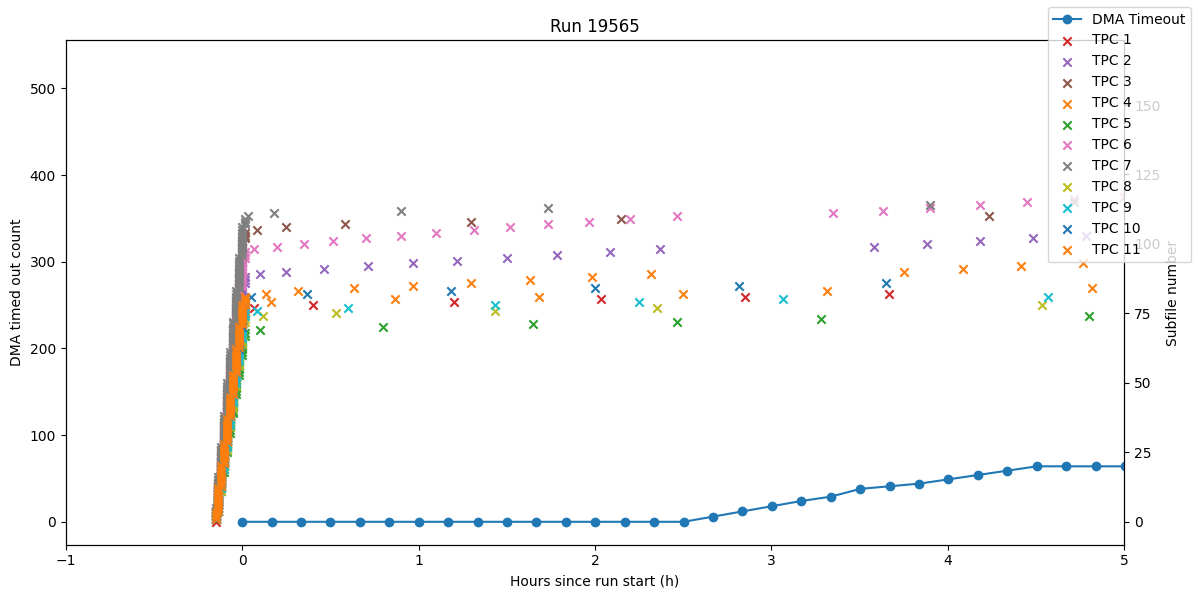

In [57]:
tpcs = [i for i in range(1,12)]  # Added run19553
run_number = 19565

plot_colors = ['tab:blue']  # Unique color for each run
subfile_colors = [
    'tab:red', 'tab:purple', 'tab:brown', 'tab:orange',
    'tab:green', 'tab:pink', 'tab:gray', 'tab:olive',
    'tab:cyan', 'tab:blue', 'tab:orange'
]
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
all_hours = []

with open(f'dma_timeout_log_run{run_number}.txt', 'r') as f:
    data = f.read()


lines = [line for line in data.strip().split('\n') if line]
times = []
counts = []
run_number_str = None
for line in lines:
    parts = [p.strip() for p in line.split('|')]
    if len(parts) < 3:
        continue
    time_str = parts[0]
    run_str = parts[1]
    count_str = parts[2]
    try:
        times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
    except Exception:
        continue
    try:
        counts.append(int(count_str.split(':')[1].strip()))
    except Exception:
        counts.append(0)
    if run_number_str is None:
        tokens = run_str.split()
        if len(tokens) >= 2:
            run_number_str = tokens[1]
reference_start = None
if times:
    reference_start = times[0]
if reference_start is None and subfile_times:
    reference_start = subfile_times[0]
times_h = [(t - reference_start).total_seconds() / 3600.0 for t in times] if reference_start and times else []

if times_h and counts:
    ax1.plot(times_h, counts, marker='o', c=plot_colors[idx % len(plot_colors)], label=f'DMA Timeout')


for idx, tpc in enumerate(tpcs):
    print(f'Processing run {tpc}')
    # Read and parse run data
    with open(f'run0{run_number}_sbnd-tpc{tpc:02d}_subfile_index.txt', 'r') as f_sub:
        subfile_data = f_sub.readlines()
    subfile_times = []
    subfile_numbers = []
    for entry in subfile_data:
        line = entry.rstrip('\n')
        m = ls_re.search(line)
        filename = None
        month_str = None
        day_str = None
        time_str = '00:00'
        if m:
            month_str = m.group('month')
            day_str = m.group('day')
            time_str = m.group('time')
            filename = m.group('filename')
        else:
            tokens = line.split()
            if not tokens:
                continue
            filename = tokens[-1]
            time_token = None
            for t in reversed(tokens[:-1]):
                if re.match(r"^\d{1,2}:\d{2}$", t):
                    time_token = t
                    break
            time_str = time_token or '00:00'
            try:
                time_index = tokens.index(time_str)
                if time_index >= 2:
                    month_str = tokens[time_index - 2]
                    day_str = tokens[time_index - 1]
            except ValueError:
                pass
        year = None
        month_file = None
        day_file = None
        if month_str and day_str:
            try:
                year = datetime.now().year
                month_file = datetime.strptime(month_str, '%b').month
                day_file = int(day_str)
            except Exception:
                year = None
                month_file = None
                day_file = None
        if year is None and filename:
            date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
            if date_match:
                year = int(date_match.group(1))
                month_file = int(date_match.group(2))
                day_file = int(date_match.group(3))
        if year is None:
            continue
        try:
            hour, minute = map(int, time_str.split(':'))
        except Exception:
            hour, minute = 0, 0
        try:
            dt = datetime(year, month_file, day_file, hour, minute)
            subfile_times.append(dt)
        except Exception:
            continue
        subfile_num = None
        if filename:
            num_match = re.search(r'_subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'subfile(\d+)_', filename)
            if not num_match:
                num_match = re.search(r'_(\d{1,4})_TPC', filename)
            if num_match:
                try:
                    subfile_num = int(num_match.group(1))
                except Exception:
                    subfile_num = None
        if subfile_num is not None:
            subfile_numbers.append(subfile_num)
    subfile_times_h = [(t - reference_start).total_seconds() / 3600.0 for t in subfile_times] if reference_start and subfile_times else []
    all_hours.extend(times_h if times_h else [])
    all_hours.extend(subfile_times_h if subfile_times_h else [])
    # Plot DMA counts vs hours since each run's start
    if subfile_times_h and subfile_numbers:
        ax2.scatter(subfile_times_h, subfile_numbers, marker='x', c=subfile_colors[idx % len(subfile_colors)], label=f'TPC {tpc}')
ax1.set_xlabel('Hours since run start (h)')
ax1.set_ylabel('DMA timed out count')
ax1.tick_params(axis='y')
ax1.set_title(f'Run {run_number}')
ax2.set_ylabel('Subfile number')
ax2.tick_params(axis='y')
if all_hours:
    ax1.set_xlim(left=0, right=max(all_hours) * 1.05)
fig.legend()
plt.xticks(rotation=45)
plt.xlim(-1,5)
plt.tight_layout()
plt.show()

Parsed 93 subfiles, example last: 2025-10-06 14:58:00, last num: 9
Parsed 156 DMA entries, last time: 2025-10-07 08:44:26, last count: 156, run: 19569


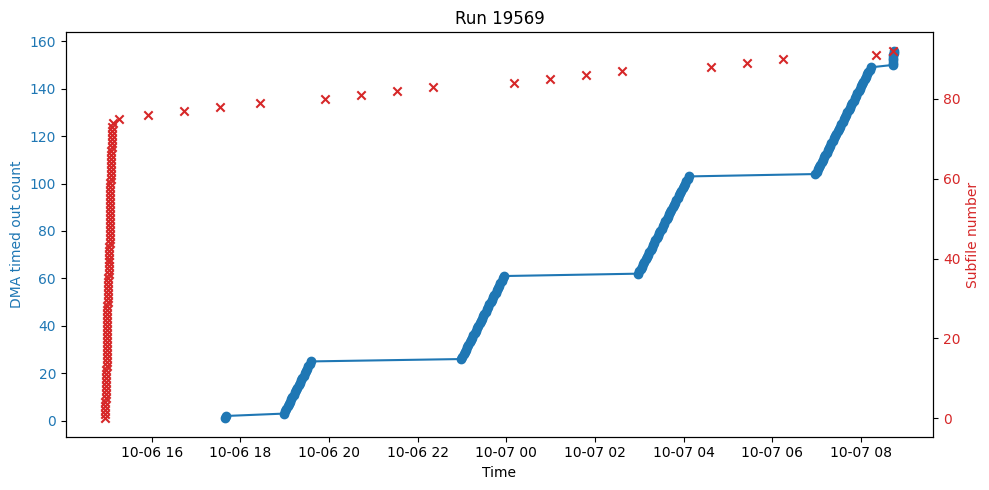

Slope of subfile number vs time for first 50 subfiles: 0.1241 subfiles/sec


In [11]:
import matplotlib.pyplot as plt
from datetime import datetime
import re

RUN = 19569

# Read raw data from txt file
with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/dma_timeout_log_run{RUN}_tpc01.txt', 'r') as f:
    data = f.read()

# Read subfile log
with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/run0{RUN}_sbnd-tpc01_subfile_index.txt', 'r') as f_sub:
    subfile_data = f_sub.readlines()

subfile_times = []
subfile_numbers = []

# Robust regex that looks for month, day, time and filename near the end of an ls -l line.
# Handles variable spacing (e.g. 'Oct  4' where day may be right-aligned).
ls_re = re.compile(r"(?P<month>\w{3})\s+(?P<day>\d{1,2})\s+(?P<time>\d{1,2}:\d{2})\s+(?P<filename>\S+)$")

for entry in subfile_data:
    line = entry.rstrip('\n')
    m = ls_re.search(line)
    filename = None
    month_str = None
    day_str = None
    time_str = '00:00'

    if m:
        month_str = m.group('month')
        day_str = m.group('day')
        time_str = m.group('time')
        filename = m.group('filename')
    else:
        # Fallback: try to grab the last token on the line as filename and parse nearby tokens for time
        tokens = line.split()
        if not tokens:
            continue
        filename = tokens[-1]
        # try to find a token that looks like HH:MM
        time_token = None
        for t in reversed(tokens[:-1]):
            if re.match(r"^\d{1,2}:\d{2}$", t):
                time_token = t
                break
        time_str = time_token or '00:00'
        # try to find a 3-letter month token before that
        try:
            time_index = tokens.index(time_str)
            if time_index >= 2:
                month_str = tokens[time_index - 2]
                day_str = tokens[time_index - 1]
        except ValueError:
            pass

    # Determine full date: prefer ls date (month_str/day_str) when present. Only use filename date if ls fields missing.
    year = None
    month_file = None
    day_file = None

    if month_str and day_str:
        # use ls-provided month/day
        try:
            year = datetime.now().year
            month_file = datetime.strptime(month_str, '%b').month
            day_file = int(day_str)
        except Exception:
            year = None
            month_file = None
            day_file = None

    if year is None and filename:
        # fallback: try to extract date from filename (e.g. 2025.10.04)
        date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
        if date_match:
            year = int(date_match.group(1))
            month_file = int(date_match.group(2))
            day_file = int(date_match.group(3))

    if year is None:
        # couldn't determine a date
        continue

    # Parse hour and minute from the time field (default to 00:00 if missing)
    try:
        hour, minute = map(int, time_str.split(':'))
    except Exception:
        hour, minute = 0, 0

    try:
        dt = datetime(year, month_file, day_file, hour, minute)
        subfile_times.append(dt)
    except Exception:
        # skip malformed dates
        continue

    # Extract subfile number from filename using a couple of patterns
    subfile_num = None
    if filename:
        num_match = re.search(r'_subfile(\d+)_', filename)
        if not num_match:
            num_match = re.search(r'subfile(\d+)_', filename)
        if not num_match:
            # as a last resort, look for digits before _TPC
            num_match = re.search(r'_(\d{1,4})_TPC', filename)
        if num_match:
            try:
                subfile_num = int(num_match.group(1))
            except Exception:
                subfile_num = None

    if subfile_num is not None:
        subfile_numbers.append(subfile_num)

# Provide a quick check of what we parsed
print(f'Parsed {len(subfile_times)} subfiles, example last: {subfile_times[-1] if subfile_times else None}, last num: {subfile_numbers[-1] if subfile_numbers else None}')

# Parse DMA log data
lines = [line for line in data.strip().split('\n') if line]
times = []
counts = []
run_number = None

for line in lines:
    parts = [p.strip() for p in line.split('|')]
    if len(parts) < 3:
        continue
    time_str = parts[0]
    run_str = parts[1]
    count_str = parts[2]
    try:
        times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
    except Exception:
        continue
    try:
        counts.append(int(count_str.split(':')[1].strip()))
    except Exception:
        counts.append(0)
    if run_number is None:
        tokens = run_str.split()
        if len(tokens) >= 2:
            run_number = tokens[1]

print(f'Parsed {len(times)} DMA entries, last time: {times[-1] if times else None}, last count: {counts[-1] if counts else None}, run: {run_number}')

# Plot with twin y-axis
fig, ax1 = plt.subplots(figsize=(10, 5))
if times and counts:
    ax1.plot(times, counts, marker='o', color='tab:blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('DMA timed out count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title(f'Run {run_number}')

ax2 = ax1.twinx()
if subfile_times and subfile_numbers:
    ax2.scatter(subfile_times, subfile_numbers, marker='x', color='tab:red')
ax2.set_ylabel('Subfile number', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Highlight subfile 410 in a different color
if 410 in subfile_numbers:
    idx_410 = subfile_numbers.index(410)
    ax2.scatter(subfile_times[idx_410], subfile_numbers[idx_410], color='orange', s=100, marker='*', label='Subfile 410 Highlight')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Use only the first 100 subfiles (if available)
n = min(50, len(subfile_times), len(subfile_numbers))
if n > 1:
    # Convert datetime to seconds since first subfile
    t0 = subfile_times[0]
    x = np.array([(t - t0).total_seconds() for t in subfile_times[:n]])
    y = np.array(subfile_numbers[:n])
    # Fit a line: y = m*x + b
    m, b = np.polyfit(x, y, 1)
    print(f"Slope of subfile number vs time for first {n} subfiles: {m:.4f} subfiles/sec")
else:
    print("Not enough subfiles to calculate slope.")

Parsed 315 subfiles, example last: 2025-10-10 23:17:00, last num: 9
Parsed 2068 DMA entries, last time: 2025-10-11 12:23:59, last count: 2068, run: 19615


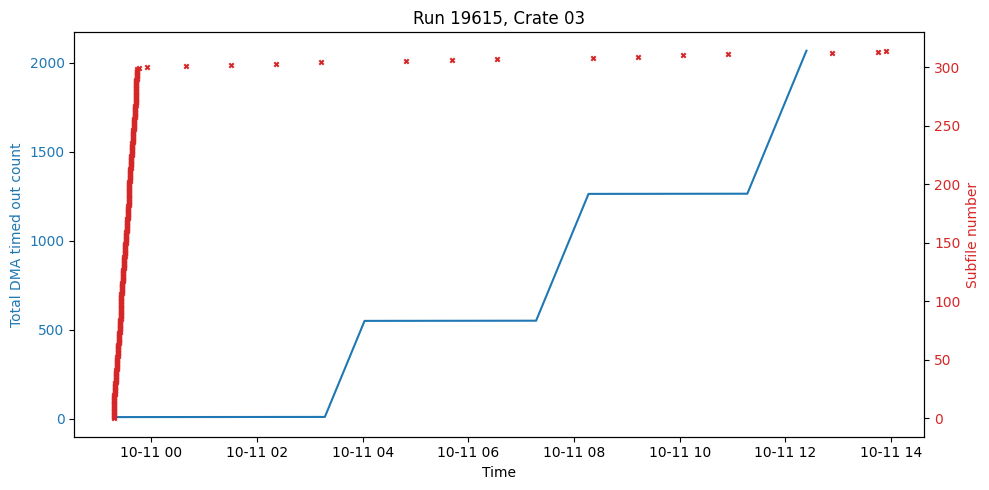

In [29]:
import matplotlib.pyplot as plt
from datetime import datetime
import re

RUN = 19615
CRATE = '03'
# Read raw data from txt file
with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/dma_timeout_log_run{RUN}_tpc{CRATE}.txt', 'r') as f:
    data = f.read()

# Read subfile log
with open(f'/nevis/riverside/data/sc5303/sbnd/continuous_readout/dma_logs/run0{RUN}_sbnd-tpc{CRATE}_subfile_index.txt', 'r') as f_sub:
    subfile_data = f_sub.readlines()

subfile_times = []
subfile_numbers = []

# Robust regex that looks for month, day, time and filename near the end of an ls -l line.
# Handles variable spacing (e.g. 'Oct  4' where day may be right-aligned).
ls_re = re.compile(r"(?P<month>\w{3})\s+(?P<day>\d{1,2})\s+(?P<time>\d{1,2}:\d{2})\s+(?P<filename>\S+)$")

for entry in subfile_data:
    line = entry.rstrip('\n')
    m = ls_re.search(line)
    filename = None
    month_str = None
    day_str = None
    time_str = '00:00'

    if m:
        month_str = m.group('month')
        day_str = m.group('day')
        time_str = m.group('time')
        filename = m.group('filename')
    else:
        # Fallback: try to grab the last token on the line as filename and parse nearby tokens for time
        tokens = line.split()
        if not tokens:
            continue
        filename = tokens[-1]
        # try to find a token that looks like HH:MM
        time_token = None
        for t in reversed(tokens[:-1]):
            if re.match(r"^\d{1,2}:\d{2}$", t):
                time_token = t
                break
        time_str = time_token or '00:00'
        # try to find a 3-letter month token before that
        try:
            time_index = tokens.index(time_str)
            if time_index >= 2:
                month_str = tokens[time_index - 2]
                day_str = tokens[time_index - 1]
        except ValueError:
            pass

    # Determine full date: prefer ls date (month_str/day_str) when present. Only use filename date if ls fields missing.
    year = None
    month_file = None
    day_file = None

    if month_str and day_str:
        # use ls-provided month/day
        try:
            year = datetime.now().year
            month_file = datetime.strptime(month_str, '%b').month
            day_file = int(day_str)
        except Exception:
            year = None
            month_file = None
            day_file = None

    if year is None and filename:
        # fallback: try to extract date from filename (e.g. 2025.10.04)
        date_match = re.search(r"(\d{4})\.(\d{1,2})\.(\d{1,2})", filename)
        if date_match:
            year = int(date_match.group(1))
            month_file = int(date_match.group(2))
            day_file = int(date_match.group(3))

    if year is None:
        # couldn't determine a date
        continue

    # Parse hour and minute from the time field (default to 00:00 if missing)
    try:
        hour, minute = map(int, time_str.split(':'))
    except Exception:
        hour, minute = 0, 0

    try:
        dt = datetime(year, month_file, day_file, hour, minute)
        subfile_times.append(dt)
    except Exception:
        # skip malformed dates
        continue

    # Extract subfile number from filename using a couple of patterns
    subfile_num = None
    if filename:
        num_match = re.search(r'_subfile(\d+)_', filename)
        if not num_match:
            num_match = re.search(r'subfile(\d+)_', filename)
        if not num_match:
            # as a last resort, look for digits before _TPC
            num_match = re.search(r'_(\d{1,4})_TPC', filename)
        if num_match:
            try:
                subfile_num = int(num_match.group(1))
            except Exception:
                subfile_num = None

    if subfile_num is not None:
        subfile_numbers.append(subfile_num)

# Provide a quick check of what we parsed
print(f'Parsed {len(subfile_times)} subfiles, example last: {subfile_times[-1] if subfile_times else None}, last num: {subfile_numbers[-1] if subfile_numbers else None}')

# Parse DMA log data
lines = [line for line in data.strip().split('\n') if line]
times = []
counts = []
run_number = None

for line in lines:
    parts = [p.strip() for p in line.split('|')]
    if len(parts) < 3:
        continue
    time_str = parts[0]
    run_str = parts[1]
    count_str = parts[2]
    try:
        times.append(datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S"))
    except Exception:
        continue
    try:
        counts.append(int(count_str.split(':')[1].strip()))
    except Exception:
        counts.append(0)
    if run_number is None:
        tokens = run_str.split()
        if len(tokens) >= 2:
            run_number = tokens[1]

print(f'Parsed {len(times)} DMA entries, last time: {times[-1] if times else None}, last count: {counts[-1] if counts else None}, run: {run_number}')

# Plot with twin y-axis
fig, ax1 = plt.subplots(figsize=(10, 5))
if times and counts:
    ax1.plot(times, counts, color='tab:blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Total DMA timed out count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title(f'Run {run_number}, Crate {CRATE}')

ax2 = ax1.twinx()
if subfile_times and subfile_numbers:
    ax2.scatter(subfile_times, subfile_numbers, marker='x', s=10, color='tab:red')
ax2.set_ylabel('Subfile number', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Highlight subfile 200 in a different color
# HIGHLIGHT_SUBFILE = 240
# if HIGHLIGHT_SUBFILE in subfile_numbers:
#     idx_410 = subfile_numbers.index(HIGHLIGHT_SUBFILE)
#     ax2.scatter(subfile_times[idx_410], subfile_numbers[idx_410], color='orange', s=100, marker='*', label=f'Subfile {HIGHLIGHT_SUBFILE} Highlight')


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()